# Random Forest Tuning

Use time-series cross-validation to rank robust random-forest configurations.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from tree_model_utils import (
    FEATURES,
    compare_bagging,
    ensure_output_dir,
    fit_decision_tree,
    fit_signal_model,
    long_short_backtest,
    make_equity_panel,
    signal_quality,
    tune_random_forest,
)

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
OUTPUT = ensure_output_dir()


In [2]:
panel = make_equity_panel(seed=114)
tuning = tune_random_forest(panel)
tuning.to_csv(OUTPUT / 'random_forest_tuning.csv', index=False)
tuning

,max_depth,min_samples_leaf,cv_rmse
1,3,75,0.0363
0,3,25,0.0363
3,5,75,0.0363
2,5,25,0.0364
5,None,75,0.0365
4,None,25,0.0369


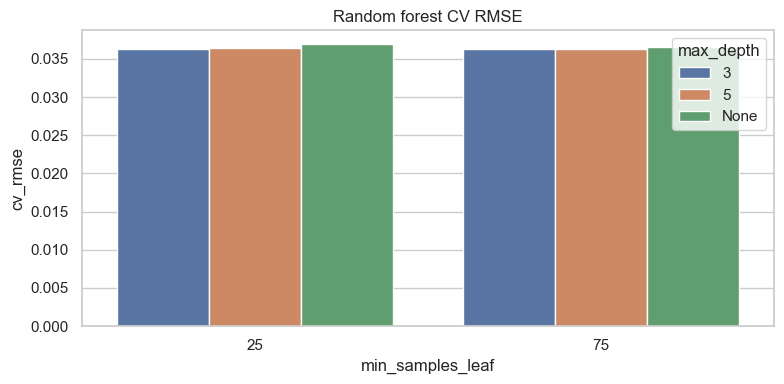

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=tuning, x='min_samples_leaf', y='cv_rmse', hue='max_depth', ax=ax)
ax.set(title='Random forest CV RMSE')
plt.tight_layout()